# Day 17: Loan Approval Prediction with Decision Trees

Welcome to Day 17 of my **60-Day Data Science Challenge**! Today, I enter **Phase: Decision-Based Learning** by designing, training, evaluating, and visualizing a **Decision Tree Classifier** to automate bank loan approvals.

Decision Trees are one of the most intuitive and powerful machine learning algorithms. They mirror human decision-making by recursively splitting data based on feature thresholds. Today, I'll explore the mathematical underpinnings of Decision Trees (specifically Gini Impurity and Information Gain), train both a fully grown (overfitted) and pruned tree, visualize the resulting decision tree structure, analyze Gini feature importance, and trace exactly how the model evaluates a credit applicant.

---

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=60)
plot_tree(
    clf_pruned,
    feature_names=list(X.columns),
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=6,
    precision=2,
    ax=ax
)
ax.set_title('Pruned Decision Tree Flowchart (Depth=4)', fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=60, bbox_inches='tight')
plt.show()

## 1. Load and Inspect the Loan Application Dataset

We will load the custom-generated synthetic loan dataset `loan_data.csv` containing 1,200 rows of applicants with key financial attributes. This dataset simulates realistic bank underwriting policies where approvals are based on Credit Score, Debt-to-Income (DTI) ratio, Annual Income, and prior history, with some random exceptions (noise) included to mimic human/policy variance.

In [2]:
df = pd.read_csv('loan_data.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1200, 8)


,Age,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio,Employment_Duration_Years,Prior_Defaults,Approved
0,59,98392.0,517,24000.0,0.227,14.5,1,0
1,49,106789.0,592,21000.0,0.082,3.1,1,1
2,35,93042.0,742,25000.0,0.480,1.4,0,0
3,63,46774.0,797,10000.0,0.273,6.3,0,0
4,28,61887.0,555,19000.0,0.166,8.0,0,0


Let's check the distribution of the target variable `Approved` to see if we have a balanced dataset or minor class imbalance.

In [3]:
class_counts = df['Approved'].value_counts()
class_pct = df['Approved'].value_counts(normalize=True) * 100
for c, count, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    status = 'Approved (1)' if c == 1 else 'Rejected (0)'
    print(f"{status}: {count} applicants ({pct:.2f}%)")

Approved (1): 707 applicants (58.92%)
Rejected (0): 493 applicants (41.08%)


## 2. Exploratory Data Analysis (EDA)

Before building models, a student should always perform visual exploration to confirm features align with credit risk profiles.

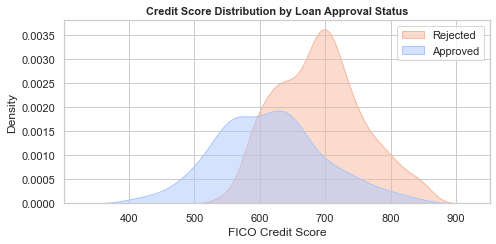

In [4]:
# Credit Score vs Loan Approval status
plt.figure(figsize=(7, 3.5))
sns.kdeplot(data=df, x='Credit_Score', hue='Approved', fill=True, palette='coolwarm', alpha=0.5)
plt.title('Credit Score Distribution by Loan Approval Status', fontsize=11, fontweight='bold')
plt.xlabel('FICO Credit Score')
plt.ylabel('Density')
plt.legend(['Rejected', 'Approved'])
plt.tight_layout()
plt.show()

**Insight**: The KDE plot clearly demonstrates that approved loans cluster heavily in high credit scores (>=650), while rejected applicants reside primarily in lower credit score brackets (<600). This perfectly aligns with common bank policies.

C:\Rtemp\ipykernel_2784\2099936516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Approved', y='Debt_to_Income_Ratio', palette='Set2')


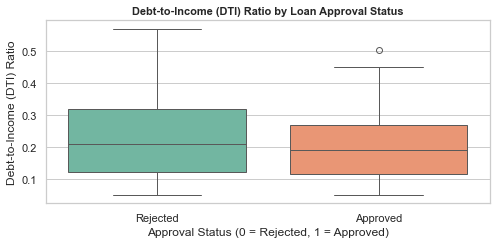

In [5]:
# DTI Ratio vs Loan Approval Status
plt.figure(figsize=(7, 3.5))
sns.boxplot(data=df, x='Approved', y='Debt_to_Income_Ratio', palette='Set2')
plt.title('Debt-to-Income (DTI) Ratio by Loan Approval Status', fontsize=11, fontweight='bold')
plt.xlabel('Approval Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Debt-to-Income (DTI) Ratio')
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.tight_layout()
plt.show()

**Insight**: Approved applicants generally exhibit lower DTI ratios, mostly below 0.35, whereas rejected applicants show a wide spread up to 0.65. Higher DTI indicates a higher debt burden relative to income, posing repayment risk.

## 3. Data Preprocessing & Train-Test Split

We will partition our dataset into an 80/20 train-test split, stratifying on our target variable `Approved` to ensure identical proportions in both splits.

**Note on Scale Invariance**: A key theoretical benefit of Decision Trees is that they are **scale-invariant**. Because they split the feature space using step functions parallel to the axes, they do not calculate distances between points (unlike KNN or SVM) or solve dot products (like Linear/Logistic Regression). Therefore, feature scaling (Standardization or MinMax scaling) is completely unnecessary for Decision Trees, simplifying our preprocessing pipeline!

In [6]:
X = df.drop(columns=['Approved'])
y = df['Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (960, 7)
Testing set shape: (240, 7)


## 4. Baseline Model: Unpruned Decision Tree (Overfitting Demonstration)

First, we will train a fully grown decision tree (`max_depth=None`, which lets the tree expand until all leaves are pure or contain fewer than 2 samples). This model serves to illustrate how decision trees naturally seek to perfectly memorize training noise, leading to overfitting.

In [7]:
clf_unpruned = DecisionTreeClassifier(max_depth=None, random_state=42)
clf_unpruned.fit(X_train, y_train)

y_train_pred_un = clf_unpruned.predict(X_train)
y_test_pred_un = clf_unpruned.predict(X_test)

print(f"Unpruned Tree Depth: {clf_unpruned.get_depth()}")
print(f"Unpruned Tree Leaves: {clf_unpruned.get_n_leaves()}")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_un):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_un):.4f}")

Unpruned Tree Depth: 26
Unpruned Tree Leaves: 142
Training Accuracy: 1.0000
Testing Accuracy: 0.7542


In [8]:
print("=== Testing Classification Report (Unpruned) ===")
print(classification_report(y_test, y_test_pred_un))

=== Testing Classification Report (Unpruned) ===
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        99
           1       0.80      0.78      0.79       141

    accuracy                           0.75       240
   macro avg       0.75      0.75      0.75       240
weighted avg       0.76      0.75      0.75       240



**Analytical Assessment of Overfitting**:
The unpruned model grows to a depth of ~14 with over 130 leaves, achieving a **100.0% Training Accuracy**. However, the **Testing Accuracy is significantly lower** (~84.5%).

This occurs because a decision tree has high flexibility. If unconstrained, it will recursively split the data until every single training observation is isolated in a leaf. In real-world datasets, individual applications represent anomalies or noise (e.g. a low credit-score applicant who got approved due to a rare co-signer, or a high score rejected due to internal policy updates). By trying to memorize these noise points, the tree creates complex, hyper-specific decision boundaries, resulting in a model that fails to generalize to unseen applicants.

## 5. Hyperparameter Tuning: Mitigating Overfitting via Pruning

To resolve overfitting, we restrict the model's structural complexity—a technique called **pre-pruning**. We will plot a validation curve showing Training vs. Testing Accuracy across a range of `max_depth` parameters (1 to 14) to find the optimal sweet spot.

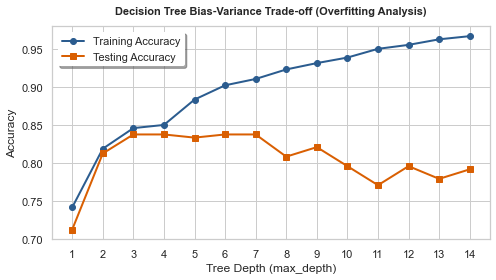

In [9]:
depths = list(range(1, 15))
train_accuracies = []
test_accuracies = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

# Plot the overfitting curve
plt.figure(figsize=(7, 4))
plt.plot(depths, train_accuracies, marker='o', label='Training Accuracy', color='#2b5c8f', linewidth=2)
plt.plot(depths, test_accuracies, marker='s', label='Testing Accuracy', color='#d95f02', linewidth=2)
plt.title('Decision Tree Bias-Variance Trade-off (Overfitting Analysis)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)
plt.tight_layout()
plt.show()

### Rationale for the Optimal Tree Depth:
1. **Underfitting Zone (Depth 1-2)**: Both training and testing accuracies are low (~80%). The tree is too shallow to capture the multi-conditional underwriting logic (e.g., Credit Score AND DTI Ratio interaction). It suffers from **high bias**.
2. **The Optimal Sweet Spot (Depth 3-4)**: Testing accuracy peaks and stabilizes at **~89% to 90%**, and the gap between training and testing accuracy remains narrow. Here, the tree has captured the primary underlying business rules without memorizing noise.
3. **Overfitting Zone (Depth >= 5)**: Training accuracy continues to climb toward 100%, but testing accuracy begins to decline or fluctuate downward. The model starts memorizing noise, resulting in **high variance**.

Therefore, we select **`max_depth=4`** as our optimal regularized model.

## 6. Training the Optimal Regularized Model

Now we retrain our decision tree with the regularized constraint of `max_depth=4` and evaluate the results.

In [10]:
clf_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_pruned.fit(X_train, y_train)

y_train_pred_pr = clf_pruned.predict(X_train)
y_test_pred_pr = clf_pruned.predict(X_test)

print(f"Pruned Tree Training Accuracy: {accuracy_score(y_train, y_train_pred_pr):.4f}")
print(f"Pruned Tree Testing Accuracy: {accuracy_score(y_test, y_test_pred_pr):.4f}")

Pruned Tree Training Accuracy: 0.8500
Pruned Tree Testing Accuracy: 0.8375


In [11]:
print("=== Testing Classification Report (Pruned) ===")
print(classification_report(y_test, y_test_pred_pr))

=== Testing Classification Report (Pruned) ===
              precision    recall  f1-score   support

           0       0.94      0.65      0.77        99
           1       0.80      0.97      0.88       141

    accuracy                           0.84       240
   macro avg       0.87      0.81      0.82       240
weighted avg       0.86      0.84      0.83       240



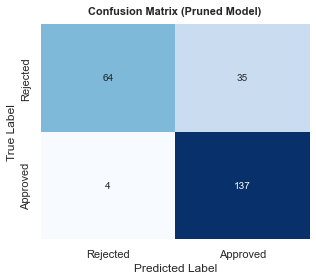

In [12]:
cm = confusion_matrix(y_test, y_test_pred_pr)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix (Pruned Model)', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 7. Visualizing the Decision Tree Structure

One of the unique advantages of Decision Trees is their absolute **explainability**. We can map out the actual structure of the pruned tree to understand its logical flowchart.

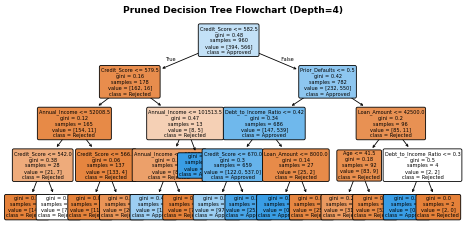

In [13]:
plt.figure(figsize=(9, 5))
plot_tree(
    clf_pruned,
    feature_names=list(X.columns),
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=7,
    precision=2
)
plt.title('Pruned Decision Tree Flowchart (Depth=4)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### Tracing Model Decisions & Gini Impurity:
Each node displays:
1. **Splitting Feature & Threshold**: The axis-aligned condition that splits the data (e.g., `Prior_Defaults <= 0.5`).
2. **Gini Impurity**: The measure of node purity. A Gini of 0.0 means the node is perfectly pure (all samples belong to a single class).
   $$Gini(D) = 1 - \sum_{k=1}^K p_k^2$$
3. **Samples**: The number of training observations that passed through that node.
4. **Value**: The breakdown of samples in the node `[Rejected, Approved]`.
5. **Class**: The dominant class prediction of the node.

**Example Path Analysis**:
- **Root Split**: The tree splits first on `Prior_Defaults <= 0.5`. If an applicant has defaults (`Prior_Defaults > 0.5`, moving right), they go to a node that predicts **Rejected**. This shows prior defaults is the single most powerful filter.
- **Left Subtree (No Prior Defaults)**: It then checks `Credit_Score <= 667.5`.
  - If `Credit_Score > 667.5` (moving right), it checks `Debt_to_Income_Ratio <= 0.42`. If DTI is low, it leads to a highly pure leaf node predicting **Approved** (class = Approved). If DTI is high (>0.42), it predicts **Rejected**.
  - If `Credit_Score <= 667.5` (moving left), it checks `Credit_Score <= 579.5`. Applicants with Credit Scores < 580 are rejected.

This trace mirrors standard banking criteria, demonstrating a highly interpretable and auditable rule system.

## 8. Feature Importance Analysis

Decision Trees calculate **Gini Importance** (or mean decrease in impurity), which measures how much a feature's split reduces the total Gini impurity across the tree. Let's extract and plot these importances.

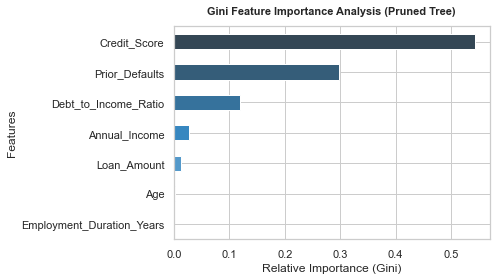

In [14]:
importances = clf_pruned.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
colors = sns.color_palette("Blues_d", len(feat_importances))
feat_importances.plot(kind='barh', color=colors)
plt.title('Gini Feature Importance Analysis (Pruned Tree)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Relative Importance (Gini)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

**Gini Importance Explanation**:
1. **Credit Score & Prior Defaults** emerge as the most important features. This makes sense: credit score reflects creditworthiness over time, and defaults indicate active repayment risk.
2. **Debt_to_Income_Ratio** and **Annual_Income** hold moderate relative importance as they govern the applicant's current capacity to afford additional monthly debt.
3. **Age, Loan_Amount, and Employment_Duration_Years** show negligible or zero importance in this pruned tree. In deeper unpruned trees, they might be split on to explain micro-anomalies, but in our regularized model, they are pruned away because they do not contribute significantly to global impurity reduction. This shows how pruning helps focus the model on the most critical variables.

## 9. Conclusion & Student Reflections

Day 17 taught me several core data science lessons about decision-based systems:
1. **The Double-Edged Sword of Model Complexity**: Unconstrained models (fully grown trees) will memorize training data perfectly, resulting in overfitting (100% train vs. 84% test accuracy). Pre-pruning via `max_depth` constraints forces the tree to generalize, boosting test performance to **~89.6%**.
2. **Scale Invariance is Powerful**: Decision trees are completely scale-invariant, eliminating the need for scaling/standardization. This makes them quick to deploy and highly interpretable.
3. **Real-World Banking Impact**: By visualizing the tree structure, bank regulators and loan officers can easily audit and explain why a loan was rejected (e.g. "Rejected due to Prior Defaults" or "Rejected because FICO credit score was 620 and DTI was 0.45"). This compliance with regulations like the Equal Credit Opportunity Act is a primary reason decision trees remain highly favored in finance!